# ✅ ***Tên Project: Dự đoán khách hàng mở tài khoản tiết kiệm***

**Nhóm 19**

**Thành viên:**
- Nguyễn Trang Thanh Trúc - MSSV: 23280011
- Trịnh Quốc Thắng - MSSV: 23280009

In [ ]:
# Import libary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

In [ ]:
# Download and import lib "gdown" to download data from google drive (open source)
# Purpose: Ensure reproducibility (tính tái lập)
!pip install gdown

In [ ]:
# Download data from google drive
import gdown
file_id = "1j4RFdHWFFMiory0yshVSu--D7kdyhxjM"
data = "bank.csv"
gdown.download(f"https://drive.google.com/uc?id={file_id}", data, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1j4RFdHWFFMiory0yshVSu--D7kdyhxjM
To: /content/bank.csv
100%|██████████| 919k/919k [00:00<00:00, 51.0MB/s]


'bank.csv'

# ✅ 1. Khám phá & tiền xử lí dữ liệu

In [ ]:
class BankDataPreprocessor:
  # 1.Define
  def __init__(self,name,path):
    self.name = name
    self._path = path
    self.data = None

  # 2. Kiểm tra định dạng file
  @staticmethod
  def is_valid_file(filepath):
      return filepath.endswith(('.csv', '.xlsx', '.json'))

  # 3 .Load data
  def load(self):
    try:
      print(f"Đang đọc file: {self._path} ...")

      if not BankDataPreprocessor.is_valid_file(self._path):
        print(f"Chưa hỗ trợ đọc loại file này")

      # Đọc nhiều loại file
      if self._path.endswith('.csv'):
        self.data = pd.read_csv(self._path)
      elif self._path.endswith('.xlsx'):
        self.data = pd.read_excel(self._path)
      elif self._path.endswith('.json'):
        self.data = pd.read_json(self._path)
      else:
        # Nếu không có đuôi thì mặc định là file csv
        self.data = pd.read_csv(self._path)

      print(f"[{self.name}] Đã load thành công: {self.data.shape}")
      return self.data

    except FileNotFoundError:
      print(f"Không tìm thấy file tại '{self._path}'")
      self.data = None
      return None

    except Exception as e:
      print(f"LỖI KHÔNG XÁC ĐỊNH: {e}")
      self.data = None
      return None

  # 4. Print
  def __repr__(self):
    try:
      # Kiểm tra xem data đã load chưa
      if self.data is not None:
        status = f"{self.data.shape[0]} dòng x {self.data.shape[1]} cột"
      else:
        status = "Chưa có dữ liệu (Empty)"

      return f"BankDataPreprocessor(Name='{self.name}', Path='{self._path}', Status='{status}')"

    except Exception as e:
      return f"BankDataPreprocessor(Lỗi hiển thị: {e})"

  # ----------------- Preprocess ------------------------
  # 1. Drop hàng quá nhiều NA (>70%)
  def remove_trash_rows(self, threshold_percent=0.7):
    initial_rows = len(self.data)
    min_count = int(threshold_percent * self.data.shape[1])

    self.data = self.data.dropna(thresh=min_count)

    deleted_rows = initial_rows - len(self.data)
    if deleted_rows > 0:
        print(f"🗑️ Đã xóa {deleted_rows} hàng 'rác' (Thiếu > {(1-threshold_percent)*100:.0f}% dữ liệu).")
    else:
        print("✨ Dữ liệu hoàn chỉnh, không có hàng nào bị xóa.")
    return self.data

  # 2. Chia thành Categorical feature và Numerical feature
  def cate_nume(self):
    catedata = self.data.select_dtypes(include= 'object')
    self.cate_features = catedata.columns.tolist()

    numedata = self.data.select_dtypes(include='number')
    self.nume_features = numedata.columns.tolist()
    return self.cate_features, self.nume_features

  # 3. Vẽ biểu đồ để kiểm tra outliners
  def visualize_outliers(self):
    # Đảm bảo đã tách cột số
    if not self.nume_features: self.cate_nume()

    print("📊 Đang vẽ biểu đồ kiểm tra Outliers...")

    # Lặp qua từng cột số để vẽ
    for col in self.nume_features:
      plt.figure(figsize=(12, 4))

      # Biểu đồ 1: Histogram (Phân phối)
      plt.subplot(1, 2, 1)
      sns.histplot(self.data[col], kde=True, color='skyblue')
      plt.title(f'Phân phối của {col}')

      # Biểu đồ 2: Boxplot (Soi Outlier)
      plt.subplot(1, 2, 2)
      sns.boxplot(x=self.data[col], color='lightpink')
      plt.title(f'Boxplot của {col}')

      plt.show()

  # 4. Xử lý Outliers
  def handle_outliers(self, col_names=None):
    if col_names is None:
      print("⚠️ Bạn chưa chọn cột!")
      return

    initial = len(self.data)
    print(f"✂️ Đang xử lý Outliers cho các cột: {col_names}")

    for col in col_names:
      # Chỉ xử lý nếu cột đó tồn tại
      if col in self.data.columns:
        Q1 = self.data[col].quantile(0.25)
        Q3 = self.data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # Giữ lại dòng an toàn (nằm trong khoảng lower và upper)
        self.data = self.data[(self.data[col] >= lower) & (self.data[col] <= upper)]

    print(f"✅ Đã loại bỏ {initial - len(self.data)} dòng Outliers.")

  # 5. Fill missing
  def missing_fill(self):
    for col in self.cate_features:
      if self.data[col].isnull().any():
        self.data[col] = self.data[col].fillna('Unknown')

    for col in self.nume_features:
      if self.data[col].isnull().any():
        self.data[col] = self.data[col].fillna(self.data[col].mean())

  # 6. Biến pdays thành biến categorical
  def feature_engineering(self):
    print("Đang tạo đặc trưng mới (Feature Engineering)...")

    # Xử lý pdays:
    # 1. pdays = -1: Chưa từng gọi (Khách mới)
    # 2. pdays > -1: Đã từng gọi (Khách cũ)
    # Tạo cột mới: 'is_new_customer' (1 nếu chưa gọi, 0 nếu đã gọi)
    self.data['is_new_customer'] = self.data['pdays'].apply(lambda x: 1 if x == -1 else 0)
    self.cate_features.append('is_new_customer')

    # Xử lý previous: Tách thành biến "Đã từng liên hệ trước đây"
    # 0: Khách mới, 1: Khách cũ
    self.data['is_returning_customer'] = self.data['previous'].apply(lambda x: 1 if x > 0 else 0)
    self.cate_features.append('is_returning_customer')

    print("✅ Đã xử lý xong pdays -> tạo cột is_new_customer.")

  # 7. Xóa cột
  def drop_columns(self, col_names):
    # Kiểm tra xem cột có trong data không rồi mới xóa
    existing_cols = [c for c in col_names if c in self.data.columns]
    if existing_cols:
      self.data = self.data.drop(columns=existing_cols)
      # Cập nhật lại danh sách feature sau khi xóa
      self.cate_nume()
      print(f" Đã xóa các cột: {existing_cols}")
    else:
      print(f"⚠️ Các cột {col_names} không tồn tại để xóa.")


  # 8. Phát hiện 1 số lỗi inconsistent cơ bản ở categorical features và sửa
  def auto_standardize_strings(self):
    print("Đang tự động dọn dẹp lỗi chính tả cơ bản...")

    # Lấy lại danh sách cột categorical mới nhất
    self.cate_nume()

    for col in self.cate_features:
        # 1. Chuyển hết về chữ thường
        self.data[col] = self.data[col].str.lower()
        # 2. Xóa khoảng trắng thừa đầu đuôi
        self.data[col] = self.data[col].str.strip()
        # 3. Thay thế các ký tự lạ phổ biến
        self.data[col] = self.data[col].str.replace(r'[.,;]', '', regex=True)

    print("✅ Đã chuẩn hóa xong")

  # 9. Tìm ra những lỗi sai khác chia phát hiện của categorical features
  def inspect_potential_errors(self, min_threshold=10):
    print("Đang tìm các giá trị lạ (xuất hiện ít hơn 10 lần)...")

    found_issue = False
    for col in self.cate_features:
        counts = self.data[col].value_counts()
        # Lọc ra các giá trị xuất hiện quá ít (nghi ngờ là lỗi typo)
        rare_values = counts[counts < min_threshold]

        if not rare_values.empty:
            found_issue = True
            print(f"\n⚠️ Cột '{col}' có các giá trị hiếm (cần check):")
            print(rare_values)

    if not found_issue:
        print("✨ Không phát hiện giá trị lạ nào đáng kể!")


  # 10. Sửa lỗi sai khác cho categorical features nếu vẫn còn
  def remap_values(self, col_name, mapping_dict):
    if col_name in self.data.columns:
      self.data[col_name] = self.data[col_name].replace(mapping_dict)
      print(f"✅ Đã sửa dữ liệu cột '{col_name}' theo quy tắc riêng.")
    else:
      print(f"Cột {col_name} không tồn tại!")


  # 11. Xử lý các giá trị 'unknown'
  def handle_unknown_values(self):
    print(" Đang xử lý các giá trị 'unknown'...")

    # NHÓM 1: Coi là lỗi thiếu tin -> Fill bằng Mode
    cols_to_fix = ['job', 'education']

    for col in cols_to_fix:
        if col in self.data.columns:
            # Thay chữ 'unknown' bằng NaN
            self.data[col] = self.data[col].replace('unknown', np.nan)

            # Tìm Mode (giá trị xuất hiện nhiều nhất)
            mode_val = self.data[col].mode()[0]

            # Fill
            self.data[col] = self.data[col].fillna(mode_val)
            print(f"   -> Cột '{col}': Đã thay 'unknown' bằng '{mode_val}'")

    # --- NHÓM 2: Coi là trạng thái bình thường -> Giữ nguyên
    # poutcome='unknown' nghĩa là Khách mới (chưa từng tiếp cận)
    # contact='unknown' nghĩa là kênh liên lạc khác -> Giữ nguyên
    print(" -> Cột 'poutcome' và 'contact': GIỮ NGUYÊN 'unknown")
    print("✅ Đã xử lý xong các giá trị unknown.")

  # 12. Mã hóa
  def encode_data(self):
    print("Đang mã hóa dữ liệu (Encoding)...")

    # Label Encoding (Cho các cột có 2 giá trị: yes/no, housing, loan...)
    le = LabelEncoder()
    binary_cols = [col for col in self.cate_features if self.data[col].nunique() == 2]

    for col in binary_cols:
      self.data[col] = le.fit_transform(self.data[col])
      print(f"   -> Label Encoded: {col}")

    # One-Hot Encoding (Cho các cột nhiều giá trị: job, marital...)
    # Cập nhật lại danh sách
    remaining_cats = [c for c in self.data.columns if self.data[c].dtype == 'object']

    if remaining_cats:
      self.data = pd.get_dummies(self.data, columns=remaining_cats, drop_first=True)
      print(f"   -> One-Hot Encoded: {remaining_cats}")

    print(f"✅ Dữ liệu sau encoding: {self.data.shape}")

  # 13. Chuẩn hóa
  def scale_data(self):
    print("Đang chuẩn hóa dữ liệu (Scaling)...")
    scaler = StandardScaler()
    self.cate_nume()

    # Không sclale biến target và biến nhị phân
    cols_to_scale = [col for col in self.nume_features if col != "deposit" and self.data[col].nunique() > 2]

    if len(cols_to_scale) == 0:
      print("⚠️ Không còn cột số nào để chuẩn hóa!")
      return

    print(f"   -> Các cột thực tế được Scale: {cols_to_scale}")

    self.data[cols_to_scale] = scaler.fit_transform(self.data[cols_to_scale])
    print("✅ Đã chuẩn hóa xong (StandardScaler).")

  # 14. Save file
  def save_processed_data(self, output_filename):
    try:
      self.data.to_csv(output_filename, index=False)
      print(f"Đã lưu dữ liệu sạch vào file: {output_filename}")
    except Exception as e:
      print(f"Lỗi khi lưu file: {e}")

In [ ]:
Data = BankDataPreprocessor("bank.csv","bank.csv")
Data.load()

Đang đọc file: bank.csv ...
[bank.csv] Đã load thành công: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [ ]:
Data.__repr__()

"BankDataPreprocessor(Name='bank.csv', Path='bank.csv', Status='11162 dòng x 17 cột')"

In [ ]:
df = Data.load()
df.info()

Đang đọc file: bank.csv ...
[bank.csv] Đã load thành công: (11162, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


In [ ]:
Data.remove_trash_rows()

✨ Dữ liệu hoàn chỉnh, không có hàng nào bị xóa.


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [ ]:
cate, nume = Data.cate_nume()
print(f"There are {len(cate)} categorical features: {cate}")
print(f"There are {len(nume)} numerical features: {nume}")

There are 10 categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
There are 7 numerical features: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


📊 Đang vẽ biểu đồ kiểm tra Outliers...


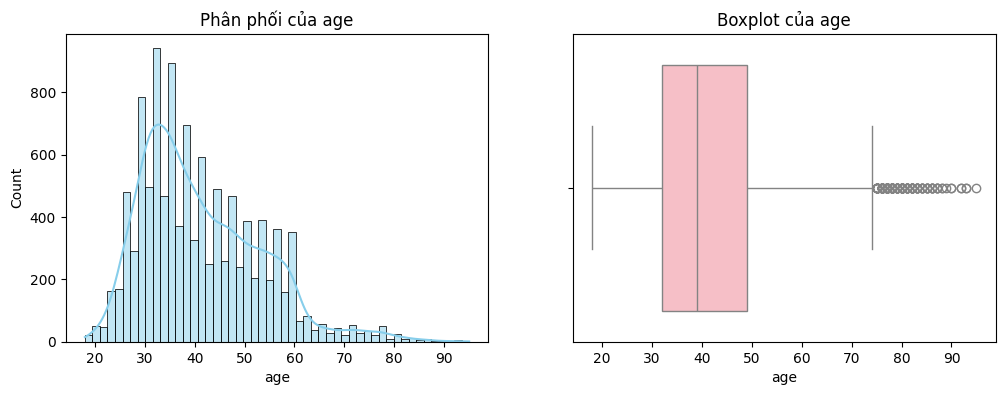

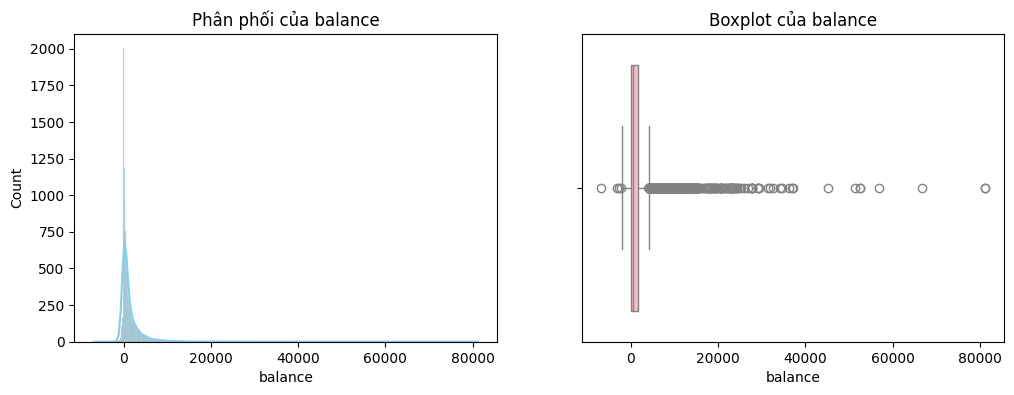

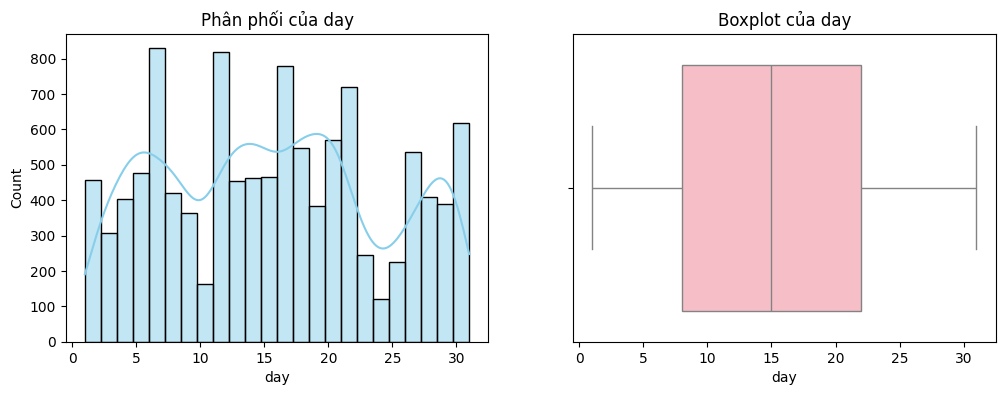

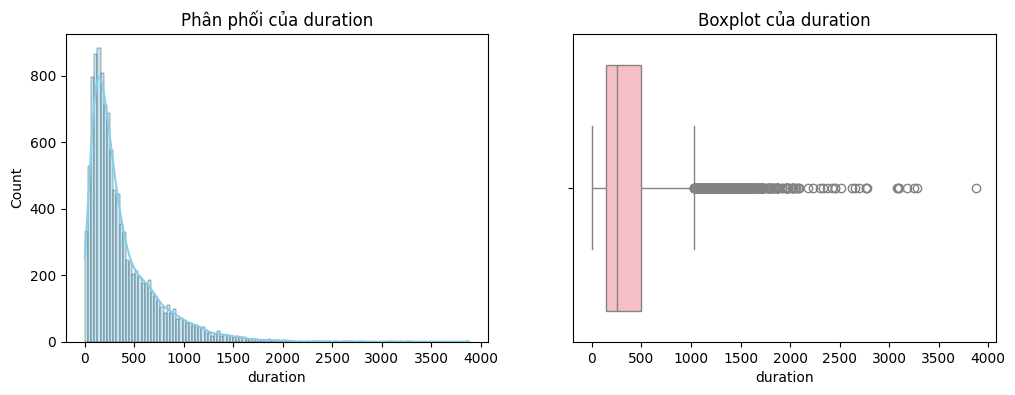

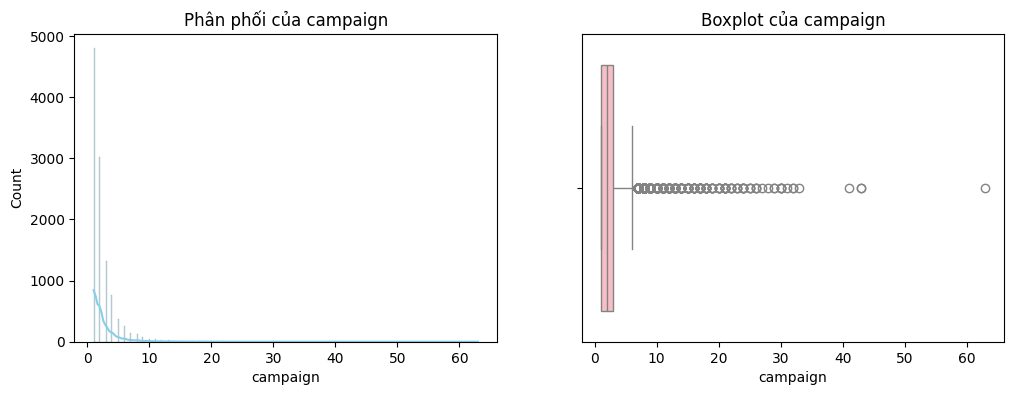

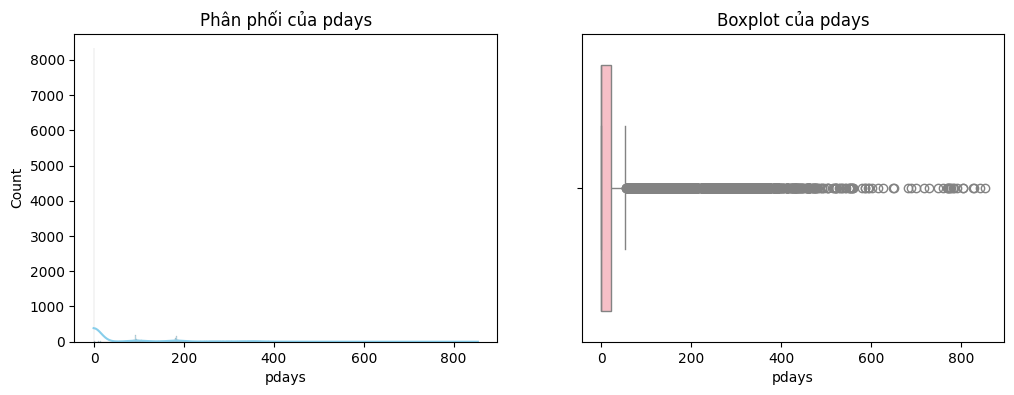

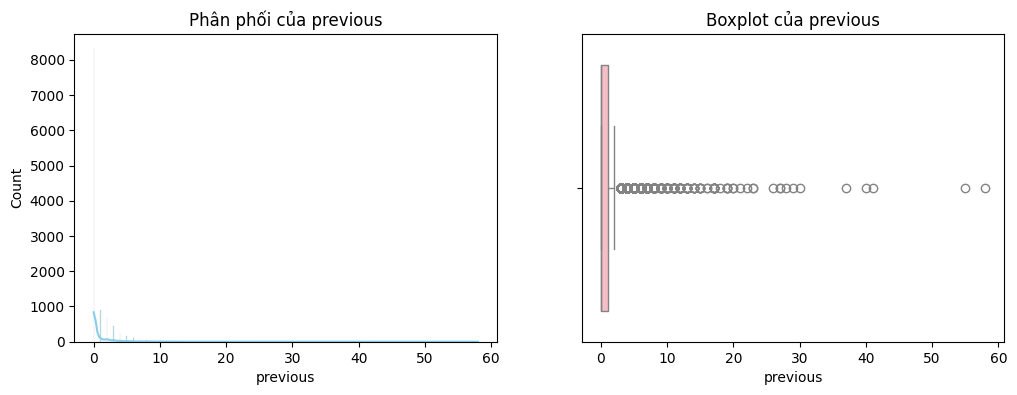

In [ ]:
Data.visualize_outliers()

- Age: Hợp lí => Không xóa
- Balance: Lệch phải và nhiều outliner nhưng hợp lí => Không xóa
- Day: Hợp lí => Không xóa
- Duration (thời lượng cuộc gọi): Có thể gây leak data => Cần sử dụng heatmap xác định tương quan trước khi xóa
- Campaign (số lần đã gọi trong chiến dịch): Có nhiều trường hợp bị gọi quá nhiều => Xóa
- Pdays: Biến phân loại trá hình, không xử lí theo biến liên tục thông thường => Chuyển thành categorical feature
- Previous (số lần đã gọi ở các chiến dịch trước): Tương tự như pdays => Chuyển thành categorical feature




In [ ]:
# Handle outliner cho Campaign
Data.handle_outliers(["campaign"])

✂️ Đang xử lý Outliers cho các cột: ['campaign']
✅ Đã loại bỏ 601 dòng Outliers.


In [ ]:
# Chuyển pdays và previous thành categorical
Data.feature_engineering()

Đang tạo đặc trưng mới (Feature Engineering)...
✅ Đã xử lý xong pdays -> tạo cột is_new_customer.


/tmp/ipython-input-1015889450.py:148: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['is_new_customer'] = self.data['pdays'].apply(lambda x: 1 if x == -1 else 0)
/tmp/ipython-input-1015889450.py:153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.data['is_returning_customer'] = self.data['previous'].apply(lambda x: 1 if x > 0 else 0)


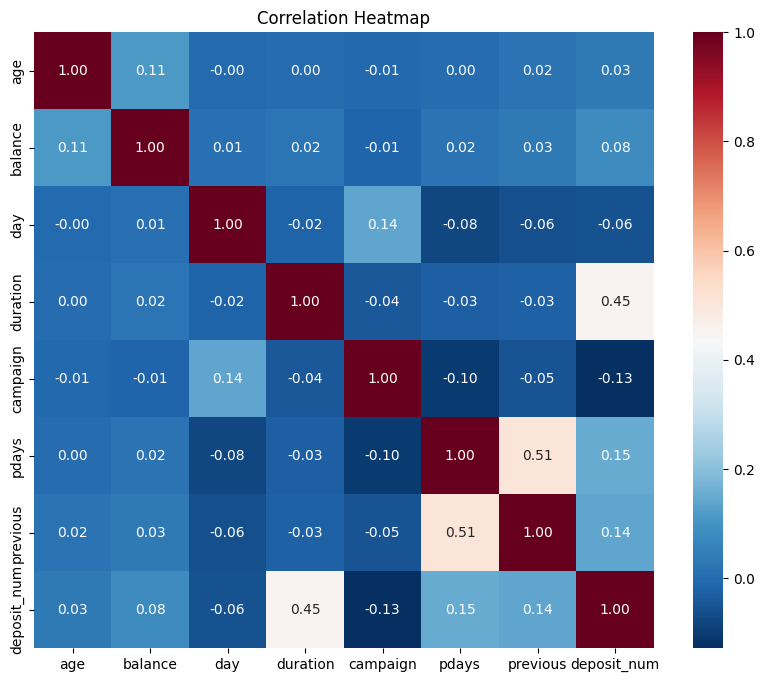

In [ ]:
# Heatmap cho duration
df_copy= df.copy()

# Chuyển target sang số
if "deposit" in df_copy.columns:
    df_copy["deposit_num"] = df_copy["deposit"].apply(lambda x: 1 if x == 'yes' else 0)

# Vẽ
plt.figure(figsize=(10, 8))

# Thêm tham số numeric_only để chỉ tính cột số
correlation_matrix = df_copy.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Duration vừa là biến có thể gây leak data vừa có độ tương quan rất cao với biến target => Xóa bỏ không đưa vào model

In [ ]:
Data.drop_columns(['duration'])

 Đã xóa các cột: ['duration']


In [ ]:
Data.auto_standardize_strings()

Đang tự động dọn dẹp lỗi chính tả cơ bản...
✅ Đã chuẩn hóa xong


In [ ]:
Data.inspect_potential_errors()

Đang tìm các giá trị lạ (xuất hiện ít hơn 10 lần)...
✨ Không phát hiện giá trị lạ nào đáng kể!


In [ ]:
Data.handle_unknown_values()

 Đang xử lý các giá trị 'unknown'...
   -> Cột 'job': Đã thay 'unknown' bằng 'management'
   -> Cột 'education': Đã thay 'unknown' bằng 'secondary'
 -> Cột 'poutcome' và 'contact': GIỮ NGUYÊN 'unknown
✅ Đã xử lý xong các giá trị unknown.


In [ ]:
Data.encode_data()

Đang mã hóa dữ liệu (Encoding)...
   -> Label Encoded: default
   -> Label Encoded: housing
   -> Label Encoded: loan
   -> Label Encoded: deposit
   -> One-Hot Encoded: ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
✅ Dữ liệu sau encoding: (10561, 42)


In [ ]:
Data.scale_data()

Đang chuẩn hóa dữ liệu (Scaling)...
   -> Các cột thực tế được Scale: ['age', 'balance', 'day', 'campaign', 'pdays', 'previous']
✅ Đã chuẩn hóa xong (StandardScaler).


In [ ]:
Data.save_processed_data("bank_processed.csv")

Đã lưu dữ liệu sạch vào file: bank_processed.csv


In [ ]:
# Read file bank_processed.csv
df2 = pd.read_csv("bank_processed.csv")
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10561 entries, 0 to 10560
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    10561 non-null  float64
 1   default                10561 non-null  int64  
 2   balance                10561 non-null  float64
 3   housing                10561 non-null  int64  
 4   loan                   10561 non-null  int64  
 5   day                    10561 non-null  float64
 6   campaign               10561 non-null  float64
 7   pdays                  10561 non-null  float64
 8   previous               10561 non-null  float64
 9   deposit                10561 non-null  int64  
 10  is_new_customer        10561 non-null  int64  
 11  is_returning_customer  10561 non-null  int64  
 12  job_blue-collar        10561 non-null  bool   
 13  job_entrepreneur       10561 non-null  bool   
 14  job_housemaid          10561 non-null  bool   
 15  jo

# ✅ 2. Model

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
import joblib
import logging
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns

def setup_logging(log_filename='training_process.log'):
  # Xóa cấu hình cũ nếu có
  for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

  # Định dạng log: [Thời gian] - [Mức độ] - [Nội dung]
  log_format = "%(asctime)s - %(levelname)s - %(message)s"

  logging.basicConfig(
    level=logging.INFO, # Ghi lại từ mức INFO trở lên (INFO, WARNING, ERROR)
    format=log_format,
    handlers=[
      logging.FileHandler(log_filename, encoding='utf-8'), # Ghi vào file
      logging.StreamHandler(sys.stdout)  # Ghi ra màn hình
    ]
  )
  logging.info(f"🚀 Bắt đầu phiên làm việc mới. Log được lưu tại: {log_filename}")

class ModelTrainer:
  def __init__(self,name,path,target_col):
    self.name = name
    self.path= path
    self.data=None
    self.target_col=target_col
    self.X_train=None
    self.X_test=None
    self.y_train=None
    self.y_test=None
    self.model=None
    self.y_pred = None
    self.y_proba = None
    self.metrics = {}
    logging = name + "_logs.log"
    setup_logging(logging)

  # nạp dữ liệu đã chuẩn hóa
  def load_data(self):
    # đọc file csv do khi chuẩn hóa đã lưu về csv
    self.data = pd.read_csv(self.path)
  # tách tập train và test

  def split_data(self,test_size=0.2):
    if self.data is None:
      logging.error("Lỗi: Dữ liệu chưa được nạp. Vui lòng gọi load_data() trước.")
      return
    if self.target_col not in self.data.columns:
      logging.error(f"Không tìm thấy cột mục tiêu '{self.target_col}' trong dữ liệu.")
      return
    X = self.data.drop(columns=[self.target_col])
    y = self.data[self.target_col]
    X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=42
      )
    self.X_train=X_train
    self.X_test=X_test
    self.y_train=y_train
    self.y_test=y_test
  # train

  def train_model(self):
    if self.model is None or self.X_train is None:
      logging.error("Lỗi: Mô hình hoặc dữ liệu chưa sẵn sàng.")
      return
    logging.info(f"--- Bắt đầu huấn luyện {self.name} ---")
    self.model.fit(self.X_train, self.y_train)
    if hasattr(self.model, 'coef_'):
      logging.info(f"Hệ số đã học: {self.model.coef_}")
    if hasattr(self.model, 'intercept_'):
      logging.info(f"Sai số chặn đã học: {self.model.intercept_}")
    logging.info("--- Huấn luyện hoàn tất ---")

  # tối ưu siêu tham số
  def optimize_params(self, param_grid, cv=5):
    if self.X_train is None:
      logging.error("Lỗi: Dữ liệu chưa sẵn sàng.")
      return

    logging.info(f"--- 🔍 Bắt đầu tối ưu hóa cho {self.name} ---")

    grid_search = GridSearchCV(
      estimator=self.model,
      param_grid=param_grid,
      cv=cv,
      scoring='accuracy',
      verbose=1
    )
    # Bắt đầu chạy thử nghiệm
    grid_search.fit(self.X_train, self.y_train)
    # Cập nhật lại model bằng phiên bản tốt nhất vừa tìm được
    self.model = grid_search.best_estimator_

    logging.info(f"✅ Tối ưu hoàn tất!")
    logging.info(f"🏆 Tham số tốt nhất: {grid_search.best_params_}")
    logging.info(f"📈 Điểm Accuracy tốt nhất trên tập train (CV): {grid_search.best_score_:.3f}")
    logging.info("---------------------------------------------")

  # đánh giá
  def evaluate(self):
    if self.model is None or self.X_test is None:
      logging.error("Lỗi: Mô hình hoặc dữ liệu chưa sẵn sàng.")
      return
    y_pred = self.model.predict(self.X_test)
    self.y_pred=y_pred
    self.metrics['accuracy'] = accuracy_score(self.y_test, y_pred)
    self.metrics['f1_macro'] = f1_score(self.y_test, y_pred, average='macro')
    self.metrics['f1_weighted'] = f1_score(self.y_test, y_pred, average='weighted')

    y_proba = None
    if hasattr(self.model, 'predict_proba'):
        # Lấy xác suất của lớp dương tính (lớp 1)
        y_proba = self.model.predict_proba(self.X_test)[:, 1]
    self.y_proba=y_proba
    if y_proba is not None:
      self.metrics['roc_auc'] = roc_auc_score(self.y_test, y_proba)
    else:
      self.metrics['roc_auc'] = None

    logging.info(f"📊 Đánh giá mô hình: {self.name}")
    logging.info(f"Accuracy: {accuracy_score(self.y_test, y_pred):.3f}")
    if y_proba is not None:
      logging.info(f"ROC AUC Score: {roc_auc_score(self.y_test, y_proba):.3f}")

    # In ra báo cáo chi tiết thay vì tính lẻ
    logging.info("\nChi tiết từng lớp:")
    report = classification_report(self.y_test, y_pred)
    # Tách báo cáo thành các dòng và log từng dòng một
    for line in report.split('\n'):
      logging.info(line)

  # ghi lại kết quả thực nghiệm
  def save_metrics(self, filename="model_comparison_metrics.csv"):
    """
    Ghi các chỉ số đánh giá của mô hình hiện tại vào tệp CSV.
    Nếu tệp tồn tại, nối thêm.
    """
    if not self.metrics:
        logging.error("Lỗi: Không có chỉ số nào để lưu. Vui lòng gọi evaluate() trước.")
        return
    metrics_data = {
        'Model Name': self.name,
        'Target Column': self.target_col,
        'Accuracy': self.metrics.get('accuracy'),
        'F1-Macro': self.metrics.get('f1_macro'),
        'F1-Weighted': self.metrics.get('f1_weighted'),
        'ROC AUC': self.metrics.get('roc_auc'),
        'Timestamp': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    new_row = pd.DataFrame([metrics_data])
    if os.path.exists(filename):
        # Nối thêm (append) mà không ghi header
        new_row.to_csv(filename, mode='a', header=False, index=False, encoding='utf-8')
        logging.info(f"✅ Đã thêm kết quả {self.name} vào tệp: {filename}")
    else:
        # Ghi mới tệp với header
        new_row.to_csv(filename, mode='w', header=True, index=False, encoding='utf-8')
        logging.info(f"✅ Đã tạo tệp và lưu kết quả {self.name} tại: {filename}")

  def save_evaluation_plots(self, output_dir="evaluation_plots"):
    if self.y_pred is None:
        logging.error("Lỗi: Mô hình chưa được đánh giá. Vui lòng gọi evaluate() trước.")
        return

    os.makedirs(output_dir, exist_ok=True)
    logging.info(f"--- Bắt đầu lưu biểu đồ đánh giá cho {self.name} tại thư mục {output_dir} ---")

    # 1. Biểu đồ Confusion Matrix
    try:
        cm = confusion_matrix(self.y_test, self.y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.y_test.unique(), yticklabels=self.y_test.unique())
        plt.title(f'Confusion Matrix - {self.name}')
        plt.ylabel('Thực tế (True Label)')
        plt.xlabel('Dự đoán (Predicted Label)')
        cm_path = os.path.join(output_dir, f'{self.name}_confusion_matrix.png')
        plt.savefig(cm_path)
        plt.close() # Đóng figure để giải phóng bộ nhớ
        logging.info(f"✅ Đã lưu Confusion Matrix tại: {cm_path}")
    except Exception as e:
        logging.error(f"Lỗi khi vẽ Confusion Matrix: {e}")

    # 2. Biểu đồ ROC Curve (Chỉ áp dụng cho mô hình có predict_proba)
    if self.y_proba is not None:
        try:
            fpr, tpr, thresholds = roc_curve(self.y_test, self.y_proba)
            roc_auc = auc(fpr, tpr)

            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'Đường cong ROC (AUC = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)')
            plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate)')
            plt.title(f'Receiver Operating Characteristic (ROC) - {self.name}')
            plt.legend(loc="lower right")
            roc_path = os.path.join(output_dir, f'{self.name}_roc_curve.png')
            plt.savefig(roc_path)
            plt.close()
            logging.info(f"✅ Đã lưu ROC Curve tại: {roc_path}")
        except Exception as e:
            logging.error(f"Lỗi khi vẽ ROC Curve: {e}")
    else:
        logging.warning("⚠️ Bỏ qua ROC Curve vì mô hình không hỗ trợ predict_proba.")

  # lưu mô hình bằng joblib
  def save_model(self, filename):
    if self.model is None:
      logging.error("Lỗi: Mô hình chưa được huấn luyện. Không thể lưu.")
      return

    joblib.dump(self.model, filename)
    logging.info(f"💾 Mô hình {self.name} đã được lưu thành công tại: {filename}")
  # nạp mô hình bằng joblib
  def load_model(self, filename):
    try:
      self.model = joblib.load(filename)
      logging.info(f"📥 Mô hình {self.name} đã được nạp thành công từ: {filename}")
    except FileNotFoundError:
      logging.error(f"Lỗi: Không tìm thấy tệp mô hình tại {filename}.")
    except Exception as e:
      logging.error(f"Lỗi khi nạp mô hình: {e}")

# class con chạy logistic regression
class LogisticRegressionModel(ModelTrainer):
  def __init__(self,name,path,target_col):
    super().__init__(name,path,target_col)
    self.model = LogisticRegression(random_state=42)

# class con chạy random forest
class RandomForestModel(ModelTrainer):
  def __init__(self,name,path,target_col):
    super().__init__(name,path,target_col)
    self.model = RandomForestClassifier(random_state=42)

In [ ]:
lr_model = LogisticRegressionModel(name="Logistric Regression Model", path="bank_processed.csv", target_col="deposit")
lr_model.load_data()
lr_model.split_data()
lr_model.train_model()
lr_model.evaluate()
param_grid_lr = {
  'C': [0.1, 1.0, 10.0],           # Độ phạt
  'solver': ['liblinear', 'lbfgs'] # Thuật toán giải
}
lr_model.optimize_params(param_grid_lr)
lr_model.evaluate()
lr_model.save_metrics("model_comparison.csv")
lr_model.save_evaluation_plots("evaluation_plots")
lr_model.save_model("my_lr_optimized.joblib")

2025-12-14 06:54:44,521 - INFO - 🚀 Bắt đầu phiên làm việc mới. Log được lưu tại: Logistric Regression Model_logs.log
2025-12-14 06:54:44,637 - INFO - --- Bắt đầu huấn luyện Logistric Regression Model ---
2025-12-14 06:54:44,879 - INFO - Hệ số đã học: [[ 3.38421415e-02 -5.01063960e-02  1.03261009e-01 -3.94686043e-01
  -3.54295350e-01 -2.64250065e-02 -1.17744755e-01 -2.52698491e-02
   2.03948163e-02  1.54468507e-03  2.53000802e-01 -3.36231614e-02
  -2.57856619e-01 -4.04458630e-01 -1.39771080e-01  4.44873661e-01
  -5.48050129e-02 -5.71957656e-02  4.51827886e-01 -2.74462964e-02
   1.42343443e-01 -2.32490236e-01  1.33536596e-01  1.82754886e-01
   3.65014774e-01 -3.45028643e-01 -1.18497141e+00 -8.18483505e-01
   1.30841354e+00 -5.14299246e-01 -1.07278260e+00 -6.41924260e-01
   1.32900922e-01  1.41011144e+00 -5.08729513e-01 -7.86165117e-01
   8.13110885e-01  6.72266923e-01  1.63094820e-01  2.09163761e+00
   1.73873921e-01]]
2025-12-14 06:54:44,885 - INFO - Sai số chặn đã học: [0.33285656]
202

In [ ]:
rf_model = RandomForestModel(name="Random Forest Model", path="bank_processed.csv", target_col="deposit")
rf_model.load_data()
rf_model.split_data()
rf_model.train_model()
rf_model.evaluate()
param_grid_rf = {
  'n_estimators': [50, 100],  # Số lượng cây
  'max_depth': [None, 5, 10], # Độ sâu cây
  'min_samples_split': [2, 5]
}
rf_model.optimize_params(param_grid_rf)
rf_model.evaluate()
rf_model.save_metrics("model_comparison.csv")
rf_model.save_evaluation_plots("evaluation_plots")
rf_model.save_model("my_rf_optimized.joblib")

2025-12-14 06:54:49,028 - INFO - 🚀 Bắt đầu phiên làm việc mới. Log được lưu tại: Random Forest Model_logs.log
2025-12-14 06:54:49,200 - INFO - --- Bắt đầu huấn luyện Random Forest Model ---
2025-12-14 06:54:51,536 - INFO - --- Huấn luyện hoàn tất ---
2025-12-14 06:54:51,714 - INFO - 📊 Đánh giá mô hình: Random Forest Model
2025-12-14 06:54:51,720 - INFO - Accuracy: 0.727
2025-12-14 06:54:51,724 - INFO - ROC AUC Score: 0.778
2025-12-14 06:54:51,725 - INFO - 
Chi tiết từng lớp:
2025-12-14 06:54:51,737 - INFO -               precision    recall  f1-score   support
2025-12-14 06:54:51,738 - INFO - 
2025-12-14 06:54:51,738 - INFO -            0       0.71      0.80      0.75      1083
2025-12-14 06:54:51,739 - INFO -            1       0.75      0.65      0.70      1030
2025-12-14 06:54:51,739 - INFO - 
2025-12-14 06:54:51,740 - INFO -     accuracy                           0.73      2113
2025-12-14 06:54:51,741 - INFO -    macro avg       0.73      0.73      0.72      2113
2025-12-14 06:54:

In [ ]:
print("\n" + "="*50)
print("XEM KẾT QUẢ SO SÁNH (model_comparison.csv):")
print("="*50)
print(pd.read_csv("model_comparison.csv").to_markdown(index=False))
print("\nCác biểu đồ (Confusion Matrix, ROC Curve) đã được lưu trong thư mục 'evaluation_plots/'")


XEM KẾT QUẢ SO SÁNH (model_comparison.csv):
| Model Name                 | Target Column   |   Accuracy |   F1-Macro |   F1-Weighted |   ROC AUC | Timestamp           |
|:---------------------------|:----------------|-----------:|-----------:|--------------:|----------:|:--------------------|
| Logistric Regression Model | deposit         |   0.704212 |   0.699449 |      0.700398 |  0.766792 | 2025-12-14 06:54:48 |
| Random Forest Model        | deposit         |   0.725982 |   0.723979 |      0.724569 |  0.781226 | 2025-12-14 06:55:19 |

Các biểu đồ (Confusion Matrix, ROC Curve) đã được lưu trong thư mục 'evaluation_plots/'


# ✅ 3. Trực quan hóa và phân tích

## Trực quan hóa dữ liệu đầu vào

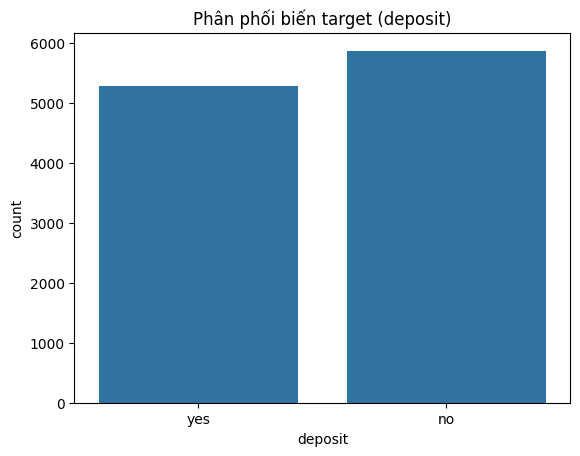

In [ ]:
# Phân phối biến target(deposit)
sns.countplot(x='deposit', data=df)
plt.title('Phân phối biến target (deposit)')
plt.show()

In [ ]:
# Quan hệ giữa các biến categorical(trừ deposit) và biến target
for col in Data.cate_features:
    if col != 'deposit':
      plt.figure(figsize=(10, 6))
      sns.countplot(x=col, hue='deposit', data=Data.data, palette=['#1abc9c', '#34495e'])
      plt.title(f'Quan hệ giữa {col} và deposit')
      plt.xticks(rotation=45)
      plt.show()
      print("\n")


Text(0, 0.5, 'Count')

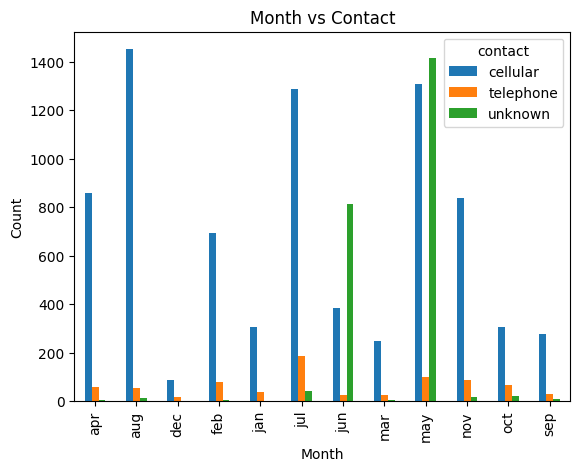

In [ ]:
# Qhan hệ giữa month và contact
pd.crosstab(df['month'], df['contact']).plot(kind='bar')
plt.title('Month vs Contact')
plt.xlabel('Month')
plt.ylabel('Count')